# RSA model testing
Testing gorgo/flippy model vs. rewritten jax model to ensure both produce identical results

In [2]:
import sys, types
sys.path.insert(0, '.')

# Patch gorgo → flippy (gorgo was renamed to flippy)
import flippy
sys.modules['gorgo'] = flippy
from flippy.hashable import hashabledict
from flippy.distributions.builtin_dists import Categorical, Beta
sys.modules['gorgo.hashable'] = flippy.hashable
_gorgo_dists = types.ModuleType('gorgo.distributions')
_gorgo_dists_builtin = types.ModuleType('gorgo.distributions.builtin_dists')
_gorgo_dists_builtin.Categorical = Categorical
_gorgo_dists_builtin.Beta = Beta
sys.modules['gorgo.distributions'] = _gorgo_dists
sys.modules['gorgo.distributions.builtin_dists'] = _gorgo_dists_builtin

import model as gorgo_model
import rsa
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ── Shared setup ──────────────────────────────────────────────────────────────
VOCAB = ['has_wings', 'jumps', 'red_spots']
V = len(VOCAB)

# gorgo uses string tuples
inst_gorgo = gorgo_model.Instance(kind='Zarpies', features=tuple(VOCAB))
kind_features_gorgo = ('has_wings', 'red_spots')

# JAX uses binary vectors
inst_jax = rsa.Instance(kind='Zarpies', features=rsa.encode(VOCAB, VOCAB))
kind_features_jax = rsa.encode(['has_wings', 'red_spots'], VOCAB)

# Utterance: generic about 'has_wings'
utt_gorgo = gorgo_model.Utterance(subj='Zarpies', feature='has_wings')
utt_jax   = rsa.Utterance(subj=1, feature_idx=0)  # subj=1 = generic, feat 0 = has_wings

COHERENCE_VALS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
print('Setup done.')

Setup done.


## 1. Literal Listener (L0) — coherence marginal

In [4]:
# gorgo L0
post_gorgo = gorgo_model.literal_listener(((utt_gorgo, inst_gorgo),))
coh_dist_gorgo = post_gorgo.marginalize(lambda x: x['coherence'])
gorgo_coh_probs = np.array([coh_dist_gorgo.prob(c) for c in COHERENCE_VALS])

# JAX L0 — marginalize over feature masks
post_jax = rsa.literal_listener([(utt_jax, inst_jax)], VOCAB)
weights_jax = np.array(post_jax['weights'])           # (N_states,)
coh_jax     = np.array(post_jax['states_coherence'])  # (N_states,)
jax_coh_probs = np.array([
    weights_jax[coh_jax == c].sum() for c in COHERENCE_VALS
])

print('L0 coherence marginals:')
print(f'{"coherence":>12}  {"gorgo":>8}  {"jax":>8}  {"diff":>8}')
for c, g, j in zip(COHERENCE_VALS, gorgo_coh_probs, jax_coh_probs):
    print(f'{c:>12.1f}  {g:>8.4f}  {j:>8.4f}  {abs(g-j):>8.1e}')

assert np.allclose(gorgo_coh_probs, jax_coh_probs, atol=1e-4), 'L0 mismatch!'
print('\n✓ L0 coherence marginals match')

L0 coherence marginals:
   coherence     gorgo       jax      diff
         0.1    0.0311    0.0311   1.1e-09
         0.2    0.0511    0.0511   1.6e-09
         0.3    0.0711    0.0711   1.7e-09
         0.4    0.0911    0.0911   5.0e-09
         0.5    0.1111    0.1111   6.6e-09
         0.6    0.1311    0.1311   1.9e-08
         0.7    0.1511    0.1511   1.5e-08
         0.8    0.1711    0.1711   4.2e-09
         0.9    0.1911    0.1911   2.1e-08

✓ L0 coherence marginals match


## 2. Speaker (S1) — utterance distribution

In [5]:
# gorgo S1
dist_s1_gorgo = gorgo_model.speaker(kind_features_gorgo, inst_gorgo)
gorgo_utt_order = [
    (subj, feat)
    for subj in ['This Zarpie', 'Zarpies']
    for feat in VOCAB
]
gorgo_s1_probs = np.array([
    dist_s1_gorgo.prob(gorgo_model.Utterance(subj=s, feature=f))
    for s, f in gorgo_utt_order
])

# JAX S1 — indices: subj=0 (This Zarpie) then subj=1 (Zarpies), each over vocab
jax_s1_probs = np.array(rsa.speaker(kind_features_jax, inst_jax, VOCAB))

print('S1 utterance probabilities:')
utt_labels = [f'({s[:4]}.., {f})' for s, f in gorgo_utt_order]
print(f'{"utterance":>25}  {"gorgo":>8}  {"jax":>8}  {"diff":>8}')
for lbl, g, j in zip(utt_labels, gorgo_s1_probs, jax_s1_probs):
    print(f'{lbl:>25}  {g:>8.4f}  {j:>8.4f}  {abs(g-j):>8.1e}')

assert np.allclose(gorgo_s1_probs, jax_s1_probs, atol=1e-4), 'S1 mismatch!'
print('\n✓ S1 utterance probs match')

S1 utterance probabilities:
                utterance     gorgo       jax      diff
      (This.., has_wings)    0.0063    0.0063   1.8e-08
          (This.., jumps)    0.0063    0.0063   1.8e-08
      (This.., red_spots)    0.0063    0.0063   1.8e-08
      (Zarp.., has_wings)    0.4854    0.4854   9.0e-07
          (Zarp.., jumps)    0.0103    0.0103   2.5e-08
      (Zarp.., red_spots)    0.4854    0.4854   9.5e-07

✓ S1 utterance probs match


## 3. Pragmatic Listener (L1) — coherence marginal

In [6]:
# gorgo L1
post_l1_gorgo = gorgo_model.pragmatic_listener(((utt_gorgo, inst_gorgo),))
coh_dist_l1_gorgo = post_l1_gorgo.marginalize(lambda x: x['coherence'])
gorgo_l1_coh = np.array([coh_dist_l1_gorgo.prob(c) for c in COHERENCE_VALS])

# JAX L1
post_l1_jax = rsa.pragmatic_listener([(utt_jax, inst_jax)], VOCAB)
weights_l1  = np.array(post_l1_jax['weights'])
coh_l1      = np.array(post_l1_jax['states_coherence'])
jax_l1_coh  = np.array([weights_l1[coh_l1 == c].sum() for c in COHERENCE_VALS])

print('L1 coherence marginals:')
print(f'{"coherence":>12}  {"gorgo":>8}  {"jax":>8}  {"diff":>8}')
for c, g, j in zip(COHERENCE_VALS, gorgo_l1_coh, jax_l1_coh):
    print(f'{c:>12.1f}  {g:>8.4f}  {j:>8.4f}  {abs(g-j):>8.1e}')

assert np.allclose(gorgo_l1_coh, jax_l1_coh, atol=1e-4), 'L1 mismatch!'
print('\n✓ L1 coherence marginals match')

L1 coherence marginals:
   coherence     gorgo       jax      diff
         0.1    0.0402    0.0402   2.6e-09
         0.2    0.0704    0.0704   1.8e-08
         0.3    0.0941    0.0941   5.3e-09
         0.4    0.1120    0.1120   4.2e-09
         0.5    0.1249    0.1249   1.1e-08
         0.6    0.1337    0.1337   5.7e-10
         0.7    0.1391    0.1391   2.0e-08
         0.8    0.1421    0.1421   6.0e-09
         0.9    0.1435    0.1435   4.5e-08

✓ L1 coherence marginals match


## 4. Speaker 2 (S2) — utterance distribution

In [7]:
# gorgo S2
dist_s2_gorgo = gorgo_model.speaker2(kind_features_gorgo, inst_gorgo)
gorgo_s2_probs = np.array([
    dist_s2_gorgo.prob(gorgo_model.Utterance(subj=s, feature=f))
    for s, f in gorgo_utt_order
])

# JAX S2
jax_s2_probs = np.array(rsa.speaker2(kind_features_jax, inst_jax, VOCAB))

print('S2 utterance probabilities:')
print(f'{"utterance":>25}  {"gorgo":>8}  {"jax":>8}  {"diff":>8}')
for lbl, g, j in zip(utt_labels, gorgo_s2_probs, jax_s2_probs):
    print(f'{lbl:>25}  {g:>8.4f}  {j:>8.4f}  {abs(g-j):>8.1e}')

assert np.allclose(gorgo_s2_probs, jax_s2_probs, atol=1e-4), 'S2 mismatch!'
print('\n✓ S2 utterance probs match')

S2 utterance probabilities:
                utterance     gorgo       jax      diff
      (This.., has_wings)    0.0236    0.0236   1.6e-09
          (This.., jumps)    0.0236    0.0236   1.6e-09
      (This.., red_spots)    0.0236    0.0236   1.6e-09
      (Zarp.., has_wings)    0.4148    0.4148   3.4e-07
          (Zarp.., jumps)    0.0996    0.0996   1.9e-08
      (Zarp.., red_spots)    0.4148    0.4148   3.4e-07

✓ S2 utterance probs match


## 5. Visualization

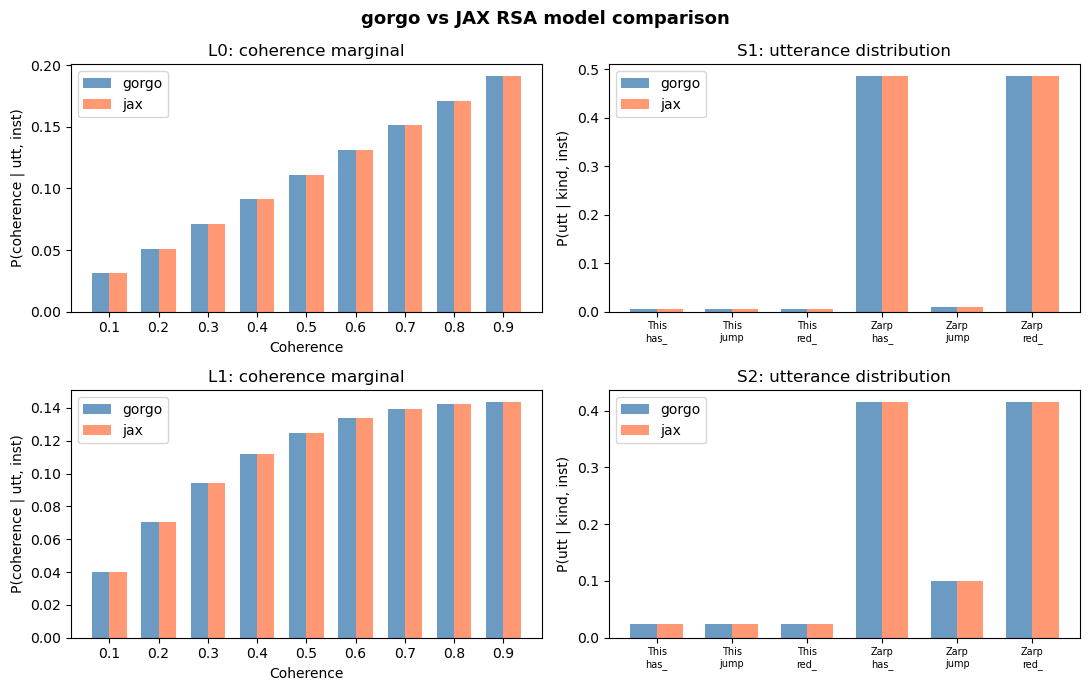

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle('gorgo vs JAX RSA model comparison', fontsize=13, fontweight='bold')

x = np.arange(len(COHERENCE_VALS))
w = 0.35
utt_short = [f'{s[:4]}\n{f[:4]}' for s, f in gorgo_utt_order]

# L0 coherence
ax = axes[0, 0]
ax.bar(x - w/2, gorgo_coh_probs, w, label='gorgo', color='steelblue', alpha=0.8)
ax.bar(x + w/2, jax_coh_probs,   w, label='jax',   color='coral',     alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'{c:.1f}' for c in COHERENCE_VALS])
ax.set_xlabel('Coherence'); ax.set_ylabel('P(coherence | utt, inst)')
ax.set_title('L0: coherence marginal')
ax.legend()

# S1 utterances
ax = axes[0, 1]
xi = np.arange(len(gorgo_utt_order))
ax.bar(xi - w/2, gorgo_s1_probs, w, label='gorgo', color='steelblue', alpha=0.8)
ax.bar(xi + w/2, jax_s1_probs,   w, label='jax',   color='coral',     alpha=0.8)
ax.set_xticks(xi); ax.set_xticklabels(utt_short, fontsize=7)
ax.set_ylabel('P(utt | kind, inst)')
ax.set_title('S1: utterance distribution')
ax.legend()

# L1 coherence
ax = axes[1, 0]
ax.bar(x - w/2, gorgo_l1_coh, w, label='gorgo', color='steelblue', alpha=0.8)
ax.bar(x + w/2, jax_l1_coh,   w, label='jax',   color='coral',     alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'{c:.1f}' for c in COHERENCE_VALS])
ax.set_xlabel('Coherence'); ax.set_ylabel('P(coherence | utt, inst)')
ax.set_title('L1: coherence marginal')
ax.legend()

# S2 utterances
ax = axes[1, 1]
ax.bar(xi - w/2, gorgo_s2_probs, w, label='gorgo', color='steelblue', alpha=0.8)
ax.bar(xi + w/2, jax_s2_probs,   w, label='jax',   color='coral',     alpha=0.8)
ax.set_xticks(xi); ax.set_xticklabels(utt_short, fontsize=7)
ax.set_ylabel('P(utt | kind, inst)')
ax.set_title('S2: utterance distribution')
ax.legend()

plt.tight_layout()
plt.show()